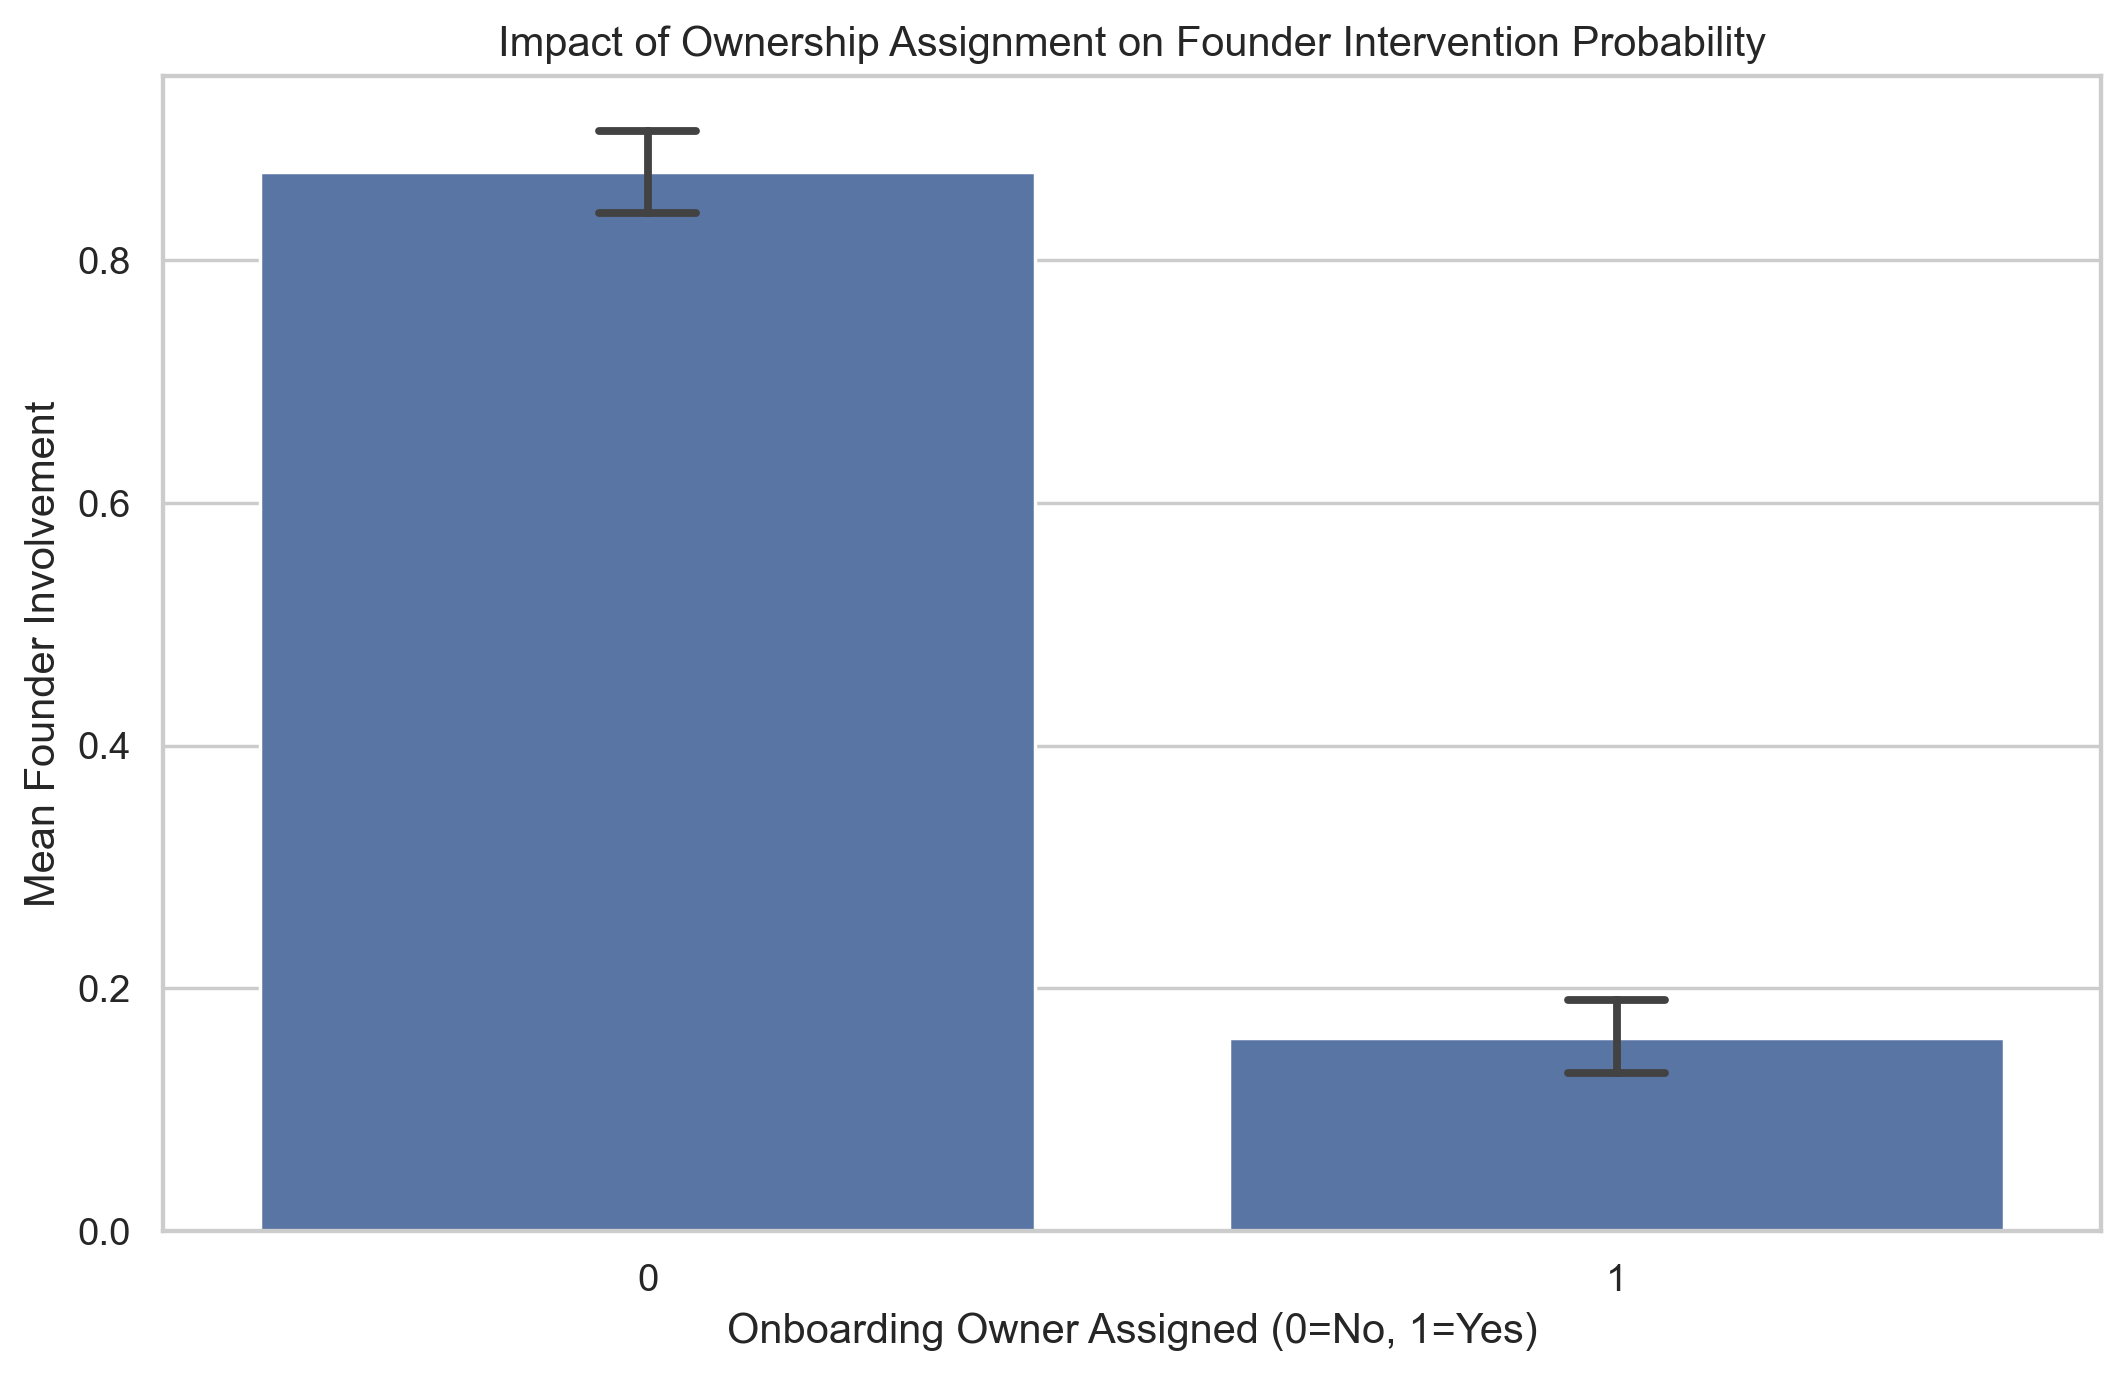

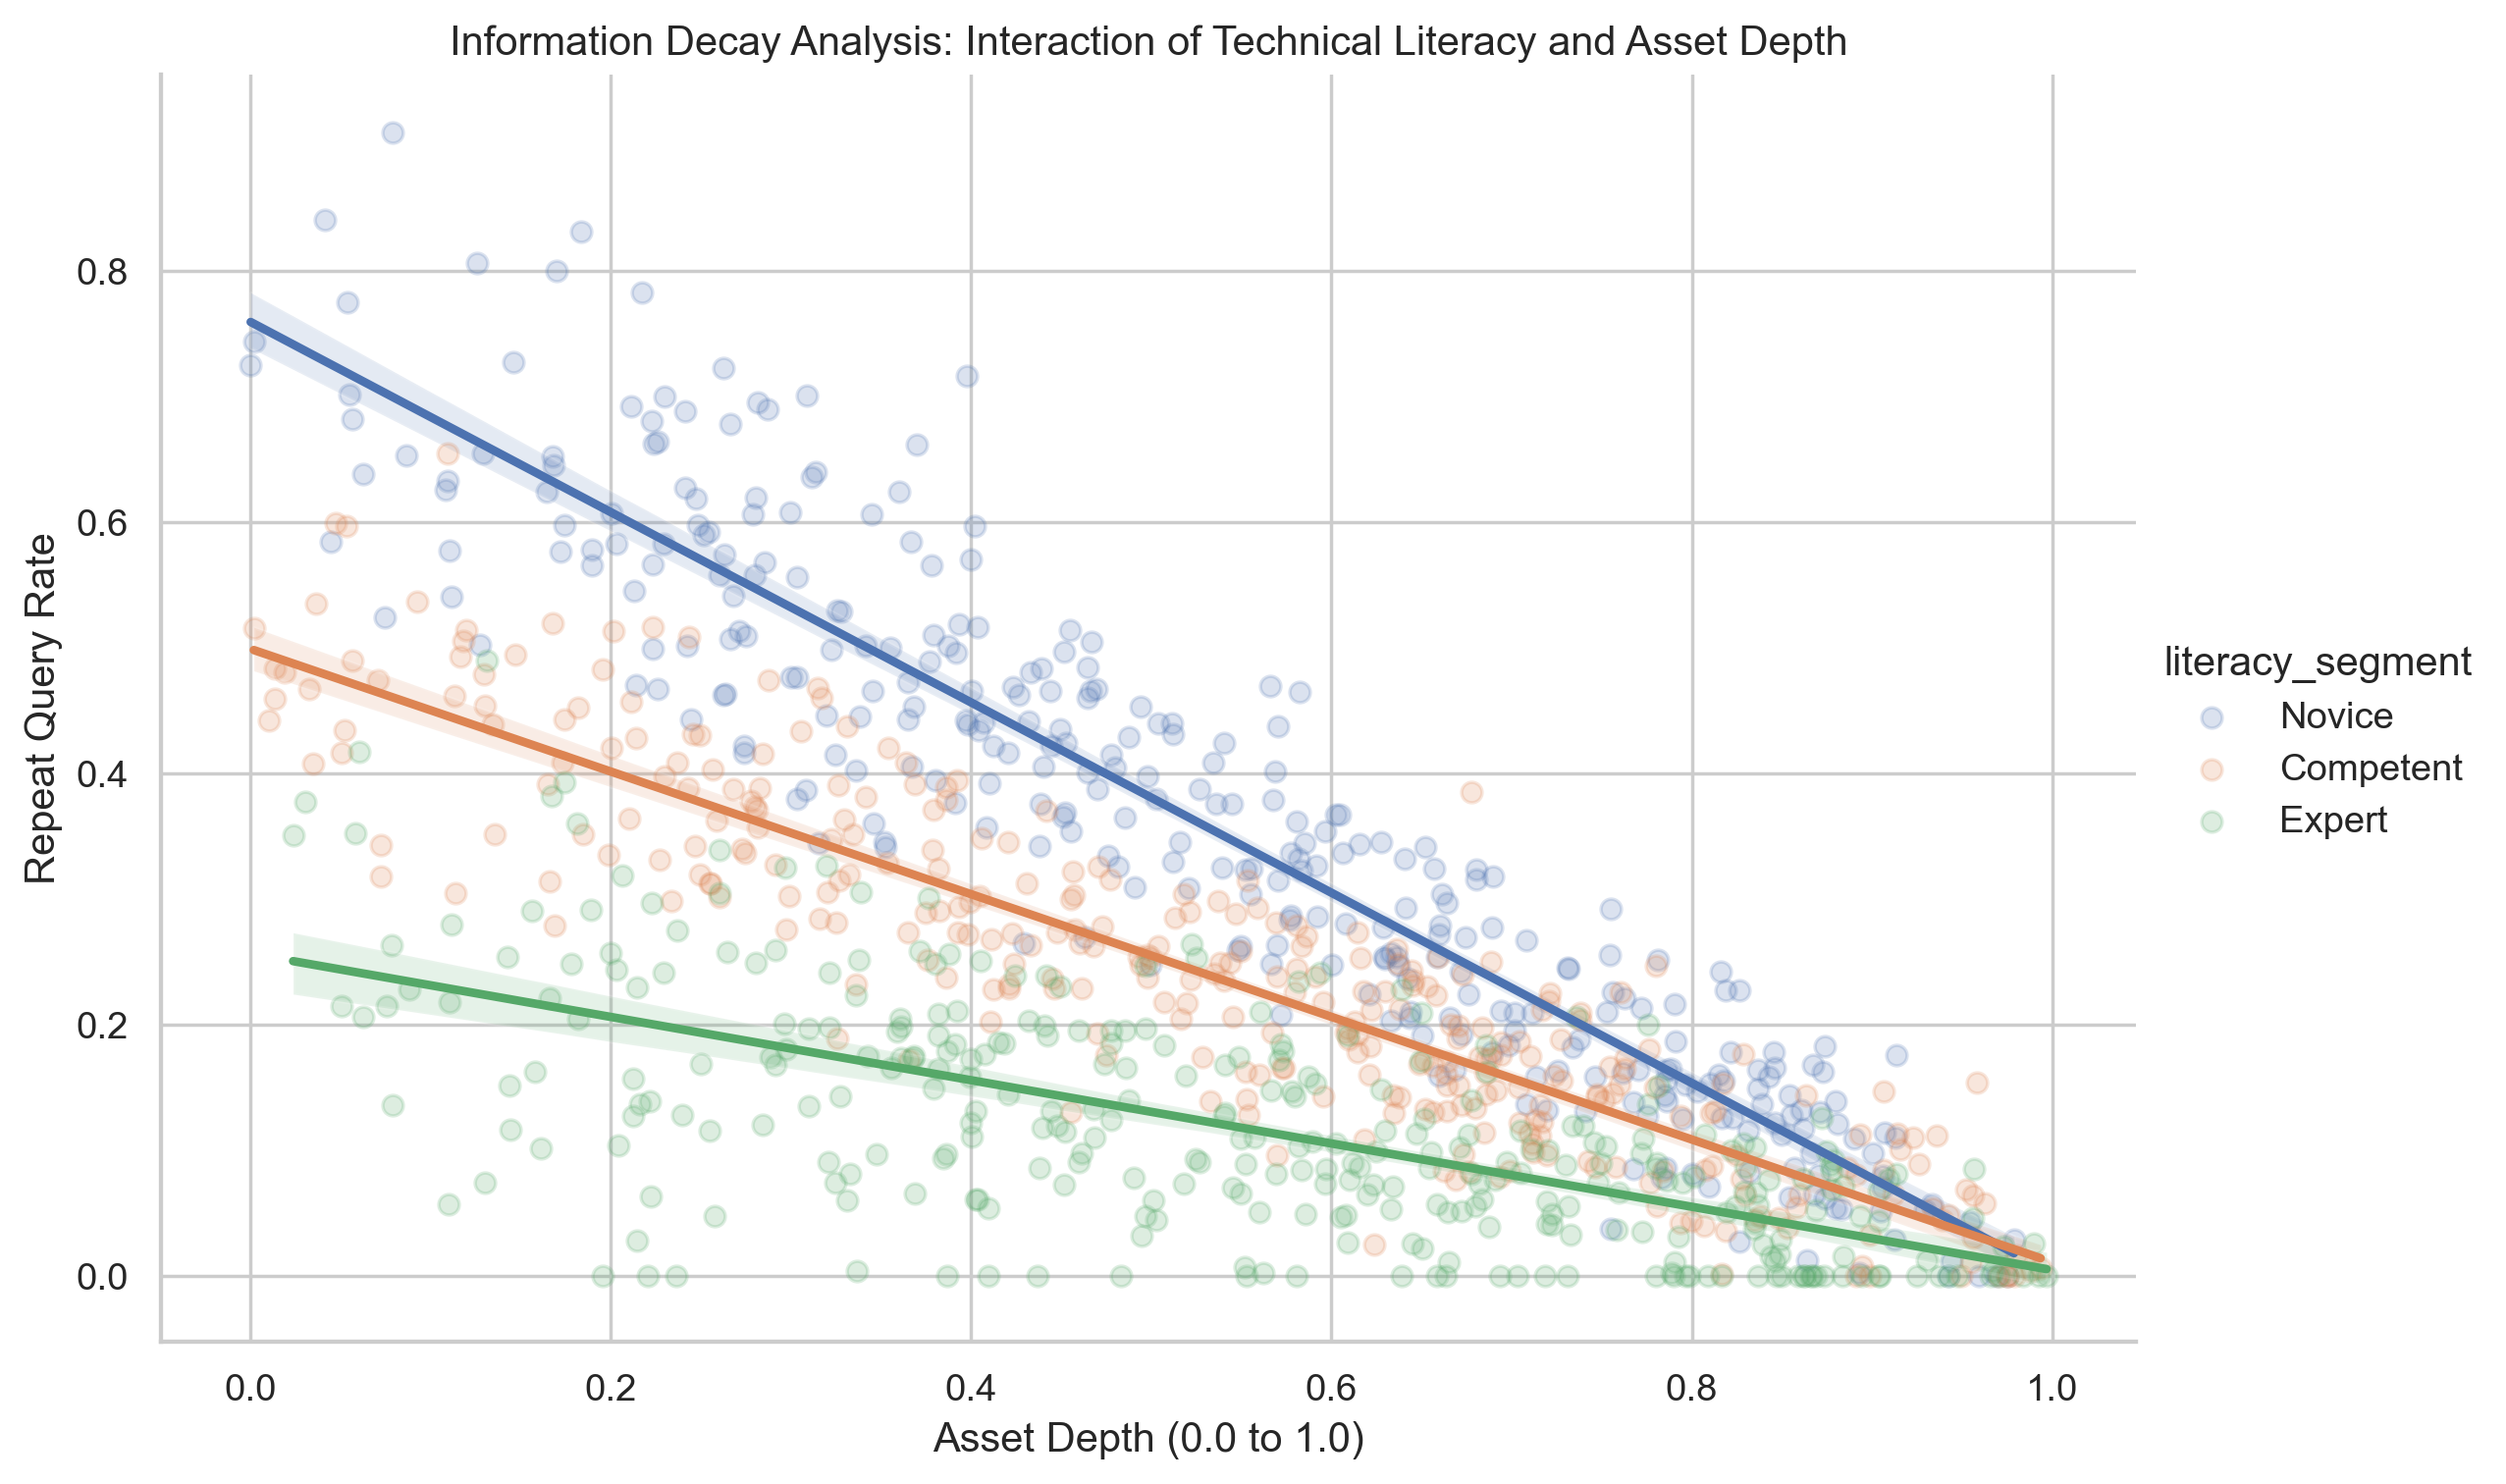

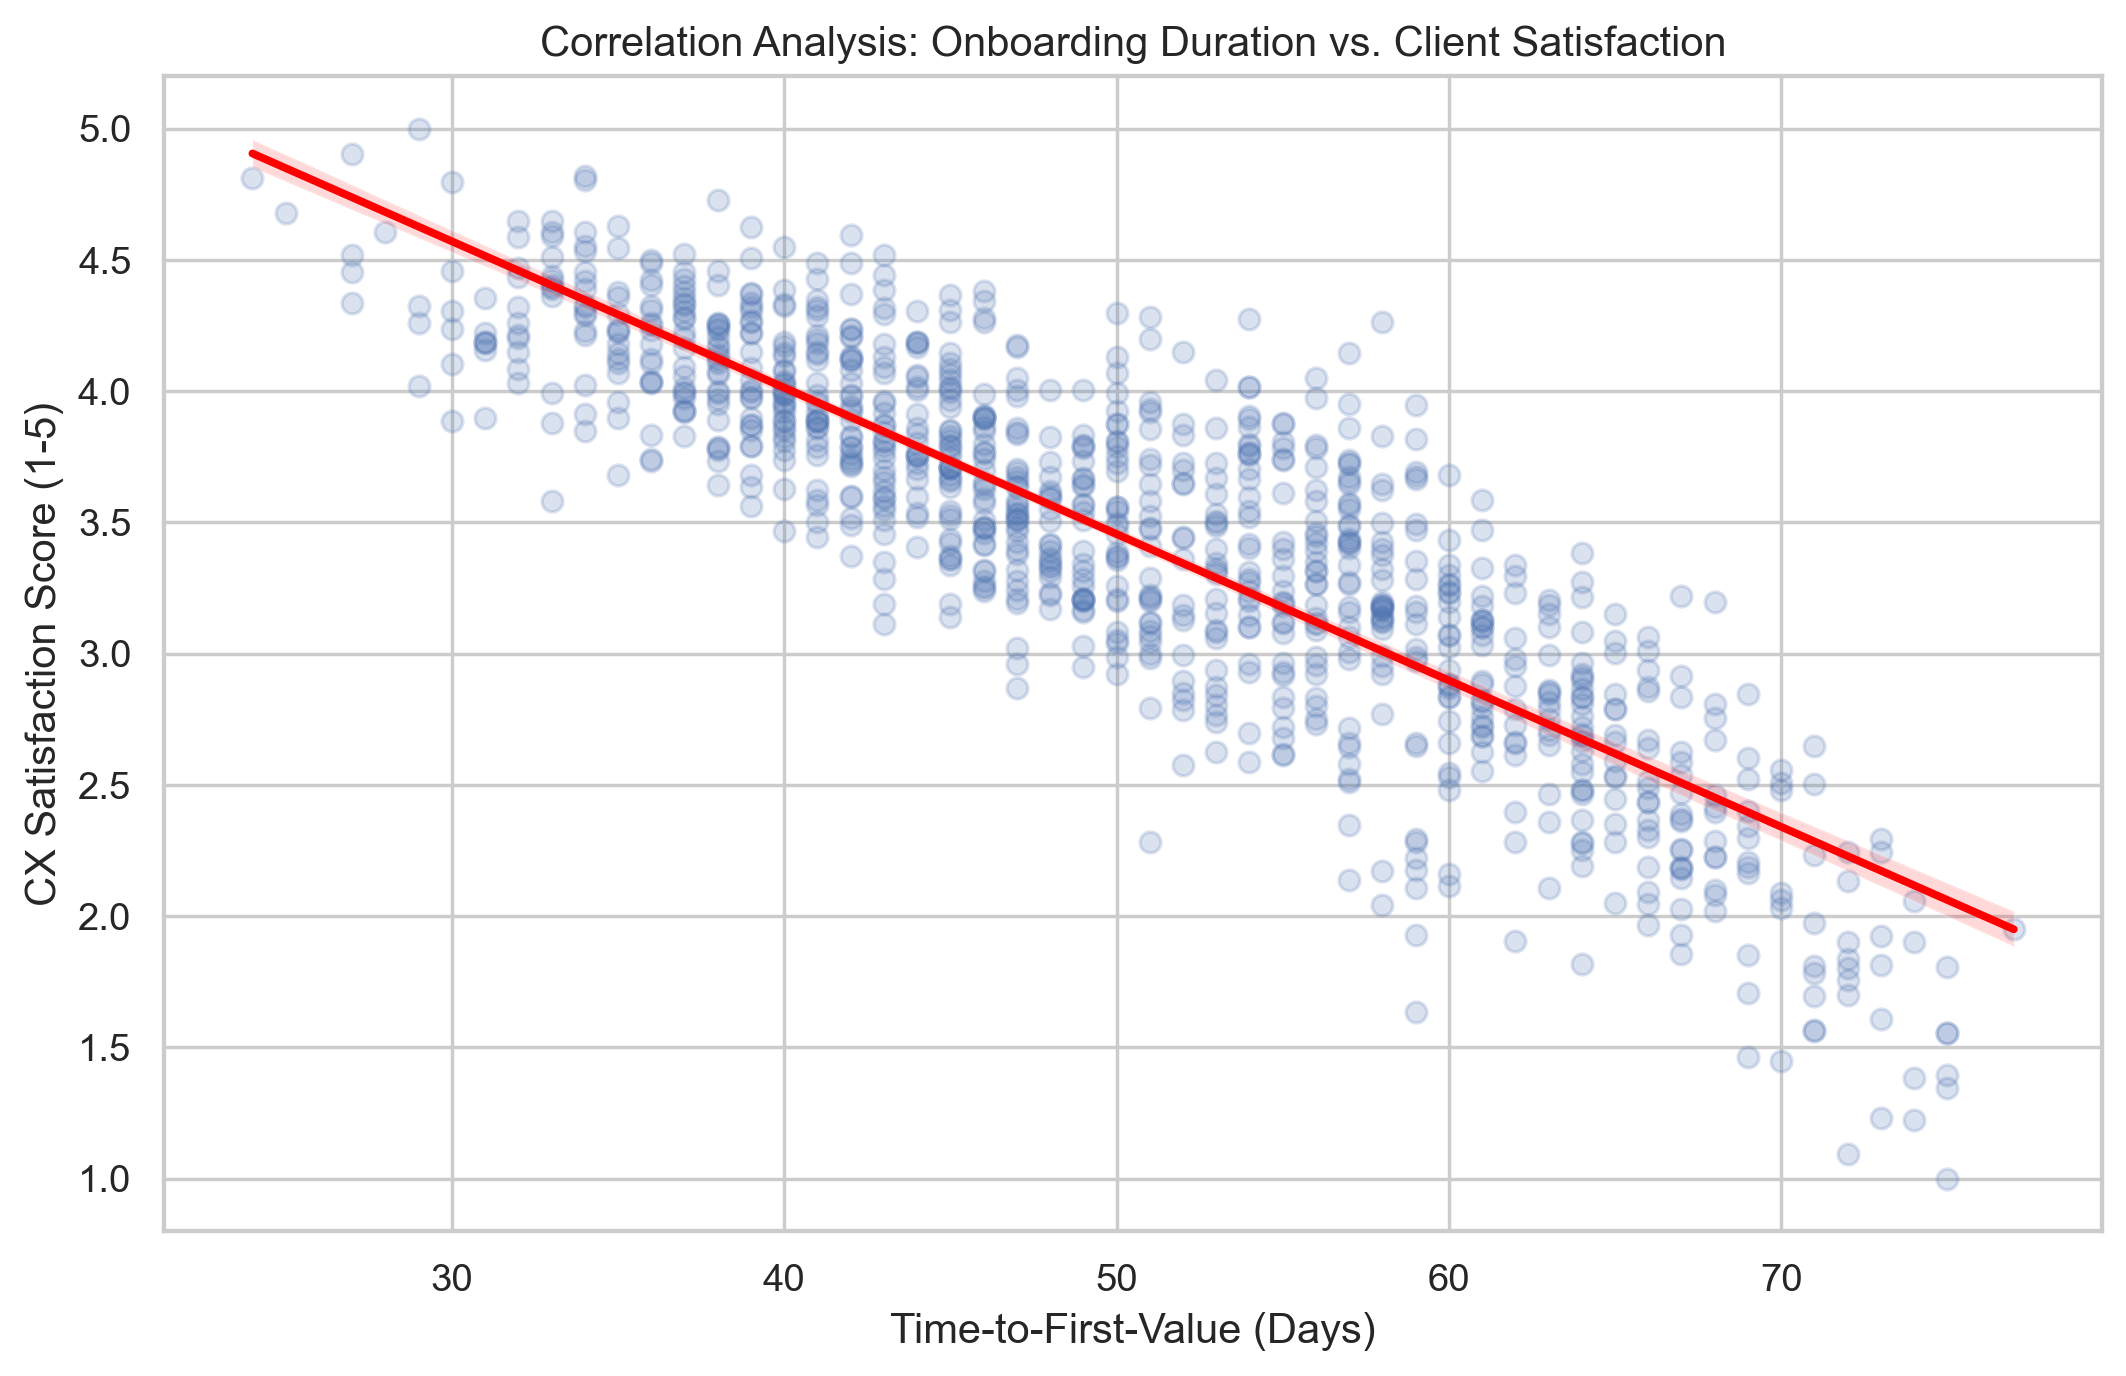

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load canonical dataset
df = pd.read_csv('../data/onboarding_data_v2.csv')

# Configuration for professional high-resolution visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 250  # High-resolution output for portfolio quality
plt.rcParams['savefig.dpi'] = 250

# --- AUDIT 1: Accountability and Resource Efficiency ---
# Objective: Quantify the correlation between owner assignment and founder involvement.
# Rationale: Validates the scaling hypothesis that dedicated ownership reduces founder dependency.
plt.figure()
sns.barplot(data=df, x='owner_assigned', y='founder_involved', estimator=np.mean, capsize=.1)
plt.title("Impact of Ownership Assignment on Founder Intervention Probability")
plt.xlabel("Onboarding Owner Assigned (0=No, 1=Yes)")
plt.ylabel("Mean Founder Involvement")
plt.show()

# --- AUDIT 2: Non-Linear Interaction (Literacy vs. Asset Depth) ---
# Objective: Determine if documentation quality has a disproportionate impact on low-literacy segments.
# Rationale: Identifies if 'Expert' clients are resilient to 'Sparse' assets compared to 'Novices'.
df['literacy_segment'] = pd.qcut(df['tech_literacy'], 3, labels=['Novice', 'Competent', 'Expert'])

# Note: lmplot handles its own figure size/dpi slightly differently; we set height for clarity
g = sns.lmplot(data=df, x='asset_depth', y='repeat_query_rate', hue='literacy_segment', 
               scatter_kws={'alpha':0.2}, line_kws={'lw':2.5}, height=6, aspect=1.5)
g.set_axis_labels("Asset Depth (0.0 to 1.0)", "Repeat Query Rate")
plt.title("Information Decay Analysis: Interaction of Technical Literacy and Asset Depth")
plt.show()

# --- AUDIT 3: Correlation of Latency to Sentiment ---
# Objective: Validate TTFV as a predictor for CX Satisfaction.
# Rationale: Establishes the business cost of onboarding delays.
plt.figure()
sns.regplot(data=df, x='ttfv_days', y='cx_satisfaction', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title("Correlation Analysis: Onboarding Duration vs. Client Satisfaction")
plt.xlabel("Time-to-First-Value (Days)")
plt.ylabel("CX Satisfaction Score (1-5)")
plt.show()

# --- SUMMARY OF AUDIT RESULTS ---
# 1. Ownership: Statistical confirmation that assignment significantly offsets founder load.
# 2. Interaction: Novice segments show significantly steeper query rates in low-asset environments.
# 3. Sentiment: Linear decay in satisfaction as TTFV increases, confirming operational urgency.

## Strategic Audit Conclusion: The Case for Systemization

The statistical audit confirms that onboarding friction is not a random occurrence but a systemic byproduct of defined operational gaps.

### 1. Scaling Risk: The Founder Bottleneck
The data demonstrates that **Ownership Ambiguity** forces high-cost executive intervention (Founder Involvement). This represents a significant scaling risk; as client volume increases, the founder becomes a single point of failure, delaying activation across the entire portfolio.

### 2. Profitability Risk: Support Entropy
The interaction between **Client Literacy** and **Asset Depth** reveals a critical "Margin Leak." 
* Expert clients are resilient and self-serve. 
* Novice clients require exponential manual support in the absence of a Single Source of Truth (SSOT).
* **Decision:** To maintain profitability, the firm must either exclusively target Expert clients or prioritize the "Comprehensive Asset" strategy to automate the Novice journey.

### 3. Retention Risk: The TTFV Death Spiral
The correlation between **Time-to-First-Value (TTFV)** and **CX Satisfaction** is strongly negative. This establishes that operational delays have a direct, quantifiable impact on client sentiment and, by extension, long-term churn probability.

---

## The Pivot to EDA (Notebook 03)
We have proven the "Rules" of our system. However, a general audit is not an action plan. To provide a high-impact deployment strategy, the **Exploratory Data Analysis (EDA)** must now focus on **Segmented Remediation**:

* **Cluster Analysis:** Identifying the specific "Danger Zone" (Low Tech + No Owner) and calculating its total impact on the portfolio.
* **Asset ROI:** Determining the exact "tipping point" of Asset Depth required to bring Novice query rates down to Expert levels.
* **Sensitivity Analysis:** Simulating how much "Founder Time" we can reclaim by moving Ownership Clarity from 0.0 to 1.0.

**Goal:** Transform these observations into a prescriptive roadmap for the final Strategic Brief.